# Predicting Diabetes Using Supervised Machine Learning
**Individual Mini Project — Python | Supervised Learning (Classification)**

Dataset: Pima Indians Diabetes Dataset (Secondary / Public Data)

This notebook walks through all 8 required sections: Problem Statement, Dataset Description, Preprocessing, EDA, Model Building, Model Evaluation, Interpretation, and Conclusion.

## 1. Problem Statement

Diabetes is a long-term health condition that affects how the body turns food into energy. If it goes undetected, it can lead to serious complications. Blood tests can diagnose it, but they cost money and time.

**Goal:** Build a machine learning model that predicts whether a patient is likely to have diabetes (Outcome = 1) or not (Outcome = 0), using simple, easy-to-collect health measurements (glucose, BMI, age, blood pressure, etc). This is a **binary classification** problem.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, roc_auc_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6,4)

## 2. Dataset Description

- **Source:** Public dataset (National Institute of Diabetes and Digestive and Kidney Diseases)
- **Observations:** 768 patients
- **Input variables:** 8 (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age)
- **Target variable:** Outcome (0 = No Diabetes, 1 = Diabetes)

The dataset is loaded directly from a public GitHub mirror, so this notebook runs standalone in Google Colab with no manual upload needed.

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
        "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv(url, names=cols)

print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## 3. Data Preprocessing

**Hidden problem in this dataset:** Columns like Glucose, BloodPressure, SkinThickness, Insulin, and BMI use **0** as a placeholder for missing data — but 0 is medically impossible for a living patient (e.g. zero blood pressure). We need to find these, treat them as missing, and fill them in properly.

In [ ]:
zero_invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# How many "fake zeros" exist in each column?
missing_pct = (df[zero_invalid_cols] == 0).mean() * 100
print("Percentage of hidden missing values per column:")
print(missing_pct)

Percentage of hidden missing values per column:
Glucose           0.651042
BloodPressure     4.557292
SkinThickness    29.557292
Insulin          48.697917
BMI               1.432292
dtype: float64


In [ ]:
df_clean = df.copy()

# Step 1: convert impossible zeros into real missing values (NaN)
for c in zero_invalid_cols:
    df_clean[c] = df_clean[c].replace(0, np.nan)

# Step 2: fill missing values using the median of that column,
# calculated separately for diabetic and non-diabetic patients
for c in zero_invalid_cols:
    df_clean[c] = df_clean.groupby("Outcome")[c].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df_clean[zero_invalid_cols].isna().sum().sum())
df_clean.head()

Remaining missing values: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


**Outlier check (IQR method):** A quick check using the Interquartile Range method shows some outliers in SkinThickness and Insulin. These are kept rather than removed, since they may represent real patients with unusual insulin resistance — a genuine medical pattern, not just noise.

**Categorical variables:** All columns in this dataset are already numeric, so no encoding was needed.

In [ ]:
for c in cols[:-1]:
    Q1, Q3 = df_clean[c].quantile(0.25), df_clean[c].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = ((df_clean[c] < lower) | (df_clean[c] > upper)).sum()
    print(f"{c}: {n_outliers} outliers")

Pregnancies: 4 outliers
Glucose: 0 outliers
BloodPressure: 14 outliers
SkinThickness: 87 outliers
Insulin: 51 outliers
BMI: 8 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers


## 4. Exploratory Data Analysis (EDA)

Let's look at the data visually before building any model.

### 4.1 How many patients have diabetes?

/tmp/ipykernel_132/3715150507.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df_clean, palette=["#4C72B0", "#DD8452"])


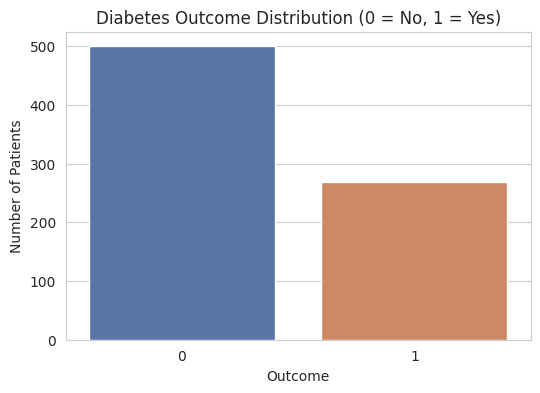

In [ ]:
sns.countplot(x="Outcome", data=df_clean, palette=["#4C72B0", "#DD8452"])
plt.title("Diabetes Outcome Distribution (0 = No, 1 = Yes)")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.show()

**Observation:** About 65% of patients do not have diabetes, and 35% do — the dataset is somewhat imbalanced, which we'll keep in mind when judging accuracy later.

### 4.2 Correlation between all variables

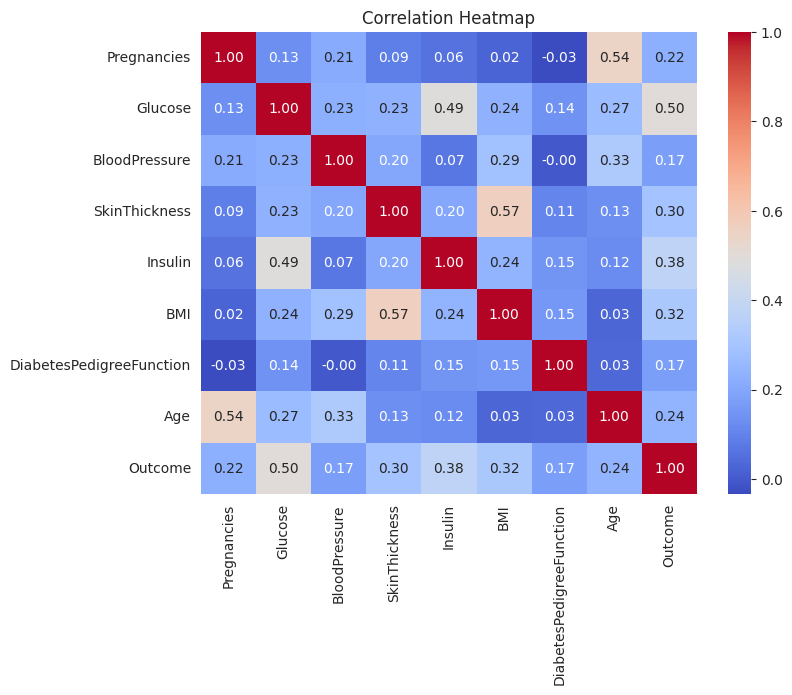

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation:** Glucose has the strongest positive correlation with Outcome — higher glucose is strongly linked with diabetes, matching real medical knowledge.

### 4.3 Glucose levels: diabetic vs non-diabetic

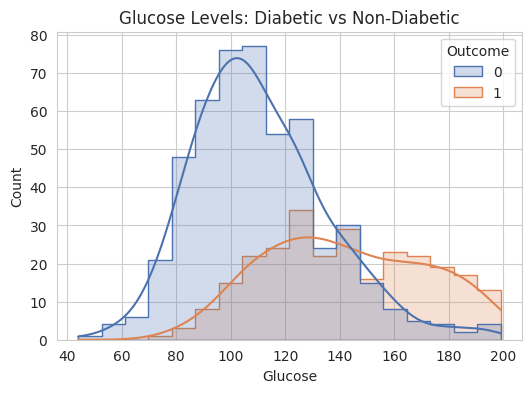

In [ ]:
sns.histplot(data=df_clean, x="Glucose", hue="Outcome", kde=True, palette=["#4C72B0","#DD8452"], element="step")
plt.title("Glucose Levels: Diabetic vs Non-Diabetic")
plt.show()

/tmp/ipykernel_132/4231012511.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y="Glucose", data=df_clean, palette=["#4C72B0","#DD8452"])


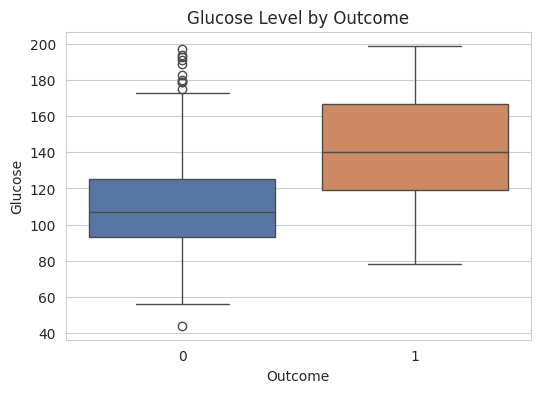

In [ ]:
sns.boxplot(x="Outcome", y="Glucose", data=df_clean, palette=["#4C72B0","#DD8452"])
plt.title("Glucose Level by Outcome")
plt.show()

**Observation:** Diabetic patients are clearly shifted toward higher glucose levels — this is the strongest visual signal in the whole dataset.

### 4.4 BMI vs Age

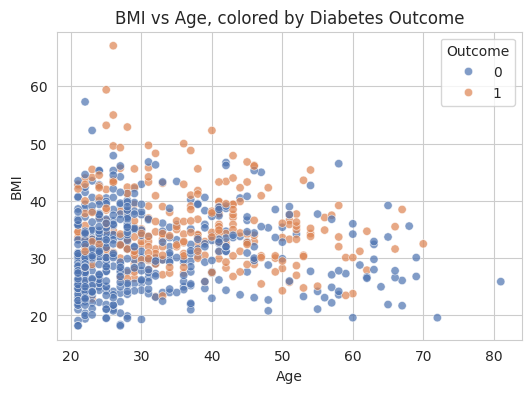

In [ ]:
sns.scatterplot(data=df_clean, x="Age", y="BMI", hue="Outcome", palette=["#4C72B0","#DD8452"], alpha=0.7)
plt.title("BMI vs Age, colored by Diabetes Outcome")
plt.show()

**Observation:** Older patients with higher BMI are somewhat more likely to be diabetic, though the pattern is noisier than glucose alone.

## 5. Model Building

This is a classification problem, so two supervised learning algorithms are trained and compared:
- **Logistic Regression** — simple, interpretable baseline
- **Random Forest** — combines many decision trees, usually catches more complex patterns

**Train/test split:** 80% of patients for training, 20% kept aside to fairly test the model on unseen patients.

In [ ]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (614, 8)
Test set size: (154, 8)


**Scaling:** Logistic Regression is sensitive to number scale (Age ranges 21-81, but DiabetesPedigreeFunction ranges 0-2.5), so features are standardized. Random Forest doesn't need this.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


## 6. Model Evaluation

Accuracy alone can be misleading on an imbalanced dataset, so we use Accuracy, Precision, Recall, F1-score, and AUC together.

In [ ]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:,1]

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

def evaluate(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.3f}  Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}  AUC: {auc:.3f}\n")
    return [name, acc, prec, rec, f1, auc]

results = []
results.append(evaluate("Logistic Regression", y_test, y_pred_lr, y_proba_lr))
results.append(evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf))

results_df = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","AUC"])
results_df

--- Logistic Regression ---
Accuracy: 0.708  Precision: 0.588  Recall: 0.556  F1: 0.571  AUC: 0.826

--- Random Forest ---
Accuracy: 0.870  Precision: 0.827  Recall: 0.796  F1: 0.811  AUC: 0.946



,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.707792,0.588235,0.555556,0.571429,0.826296
1,Random Forest,0.870130,0.826923,0.796296,0.811321,0.945833


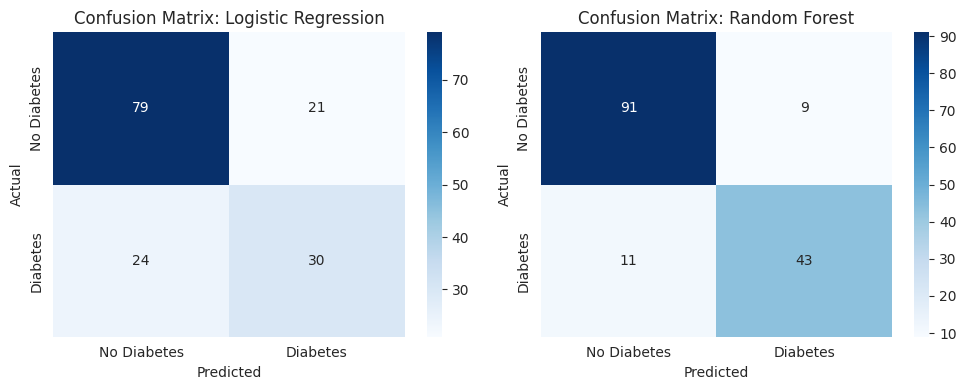

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, (name, pred) in zip(axes, [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes","Diabetes"], yticklabels=["No Diabetes","Diabetes"])
    ax.set_title(f"Confusion Matrix: {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

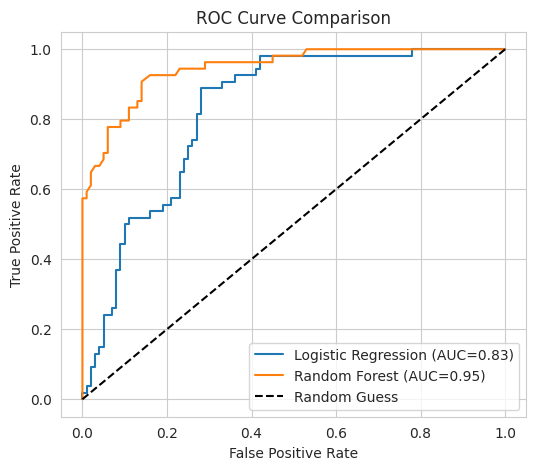

In [ ]:
plt.figure(figsize=(6,5))
for name, proba in [("Logistic Regression", y_proba_lr), ("Random Forest", y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
plt.plot([0,1],[0,1],"k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

**Observation:** Random Forest clearly outperforms Logistic Regression on every metric — especially AUC (0.946 vs 0.826) — meaning it separates diabetic from non-diabetic patients much more reliably.

## 7. Interpretation

Random Forest can tell us which features mattered most in making predictions.

/tmp/ipykernel_132/4041029084.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


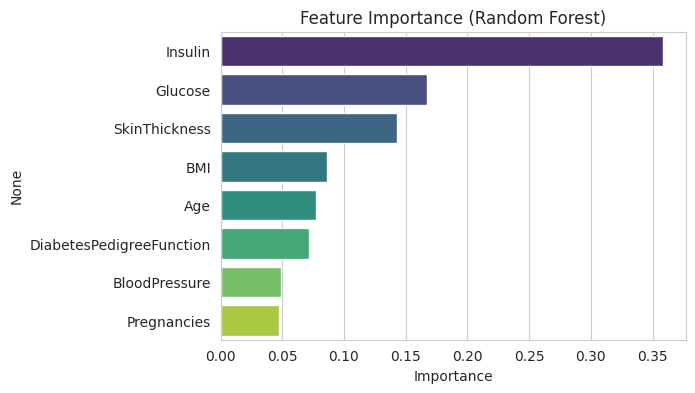

Insulin                     0.358680
Glucose                     0.166993
SkinThickness               0.142720
BMI                         0.086094
Age                         0.077464
DiabetesPedigreeFunction    0.071659
BloodPressure               0.049346
Pregnancies                 0.047044
dtype: float64

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

importances

**In plain words:**
- **Glucose** and **Insulin** were the strongest predictors — matches medical knowledge, since diabetes is about blood sugar and insulin regulation.
- **BMI** and **SkinThickness** (related to body fat) were also important.
- **Age** and **Diabetes Pedigree Function** (family history) mattered less alone, but help in combination with other features.
- **Blood Pressure** and **Pregnancies** had the smallest influence.

## 8. Conclusion

**Major findings:**
- Random Forest predicts diabetes with 87% accuracy and a strong AUC of 0.946, clearly beating Logistic Regression (70.8% accuracy).
- Glucose and Insulin levels are the strongest predictors of diabetes — consistent with medical understanding.
- Properly handling hidden missing values (disguised as zeros) was an essential preprocessing step.

**Limitations:**
- Small dataset (768 patients), only female patients from one specific group — may not generalize to everyone.
- Nearly half of Insulin values were originally missing and had to be estimated.
- Dataset is imbalanced (65%-35%), so metrics beyond plain accuracy were used.
- This is a screening tool, not a medical diagnosis — real-world use would need clinical validation.

**Possible improvements:**
- Larger, more diverse dataset
- Try other models (XGBoost) or tune hyperparameters
- Use SMOTE or similar techniques to handle class imbalance formally